### Change the location to where the dataset is located

In [1]:
import os
os.chdir('../..')
print(f"Changed directory to {os.getcwd()}")

Changed directory to /Users/manu/lib/NMF_github


### Import GeneData.py file where all the functions are defined

In [2]:
from GeneData import* 

### Read Tusi *et al.* data

Data are assumed to be in the CSV file downloaded from GEO accession #GSM2388072. ReadTusiGEOCSV returns a numpy 2D ndarray with one gene per row and one cell per column. 

In [6]:
Xgt = ReadTusiGEOCSV('example/Tusi1803/GSM2388072_basal_bone_marrow.filtered_normalized_counts.csv')

### Scale gene expression between [0,1]

In [29]:
XgtScaled = scaleGeneExpression(Xgt)

### Run NMF

In [32]:
Wgm,Hmt,frobNorm = NMF(XgtScaled,17,0.005) 

iteration=124   FrobNorm=436.8295643560404
Time : 88.75075626373291


#### Plot convergence

Text(0.5, 1.0, 'Convergence of Frobenius norm')

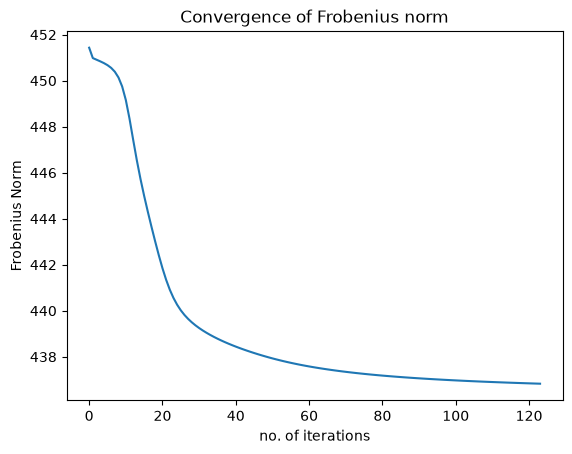

In [33]:
plt.plot(frobNorm) ; plt.xlabel("no. of iterations"); plt.ylabel("Frobenius Norm");plt.title("Convergence of Frobenius norm") 

### Save behaviors

In [34]:
with open('example/Tusi1803/Hmt17Behaviors.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerows(Hmt)

### Visualization

#### Read SPRING plot coordinates

In [26]:
tusi_orig_coord = np.loadtxt("example/Tusi1803/origtusicoords.txt", delimiter=",")

Reflect about the y-axis to match the plots in Tusi *et al.*

In [27]:
tusi_orig_coord[:,1] *= -1

#### Plot the behaviors

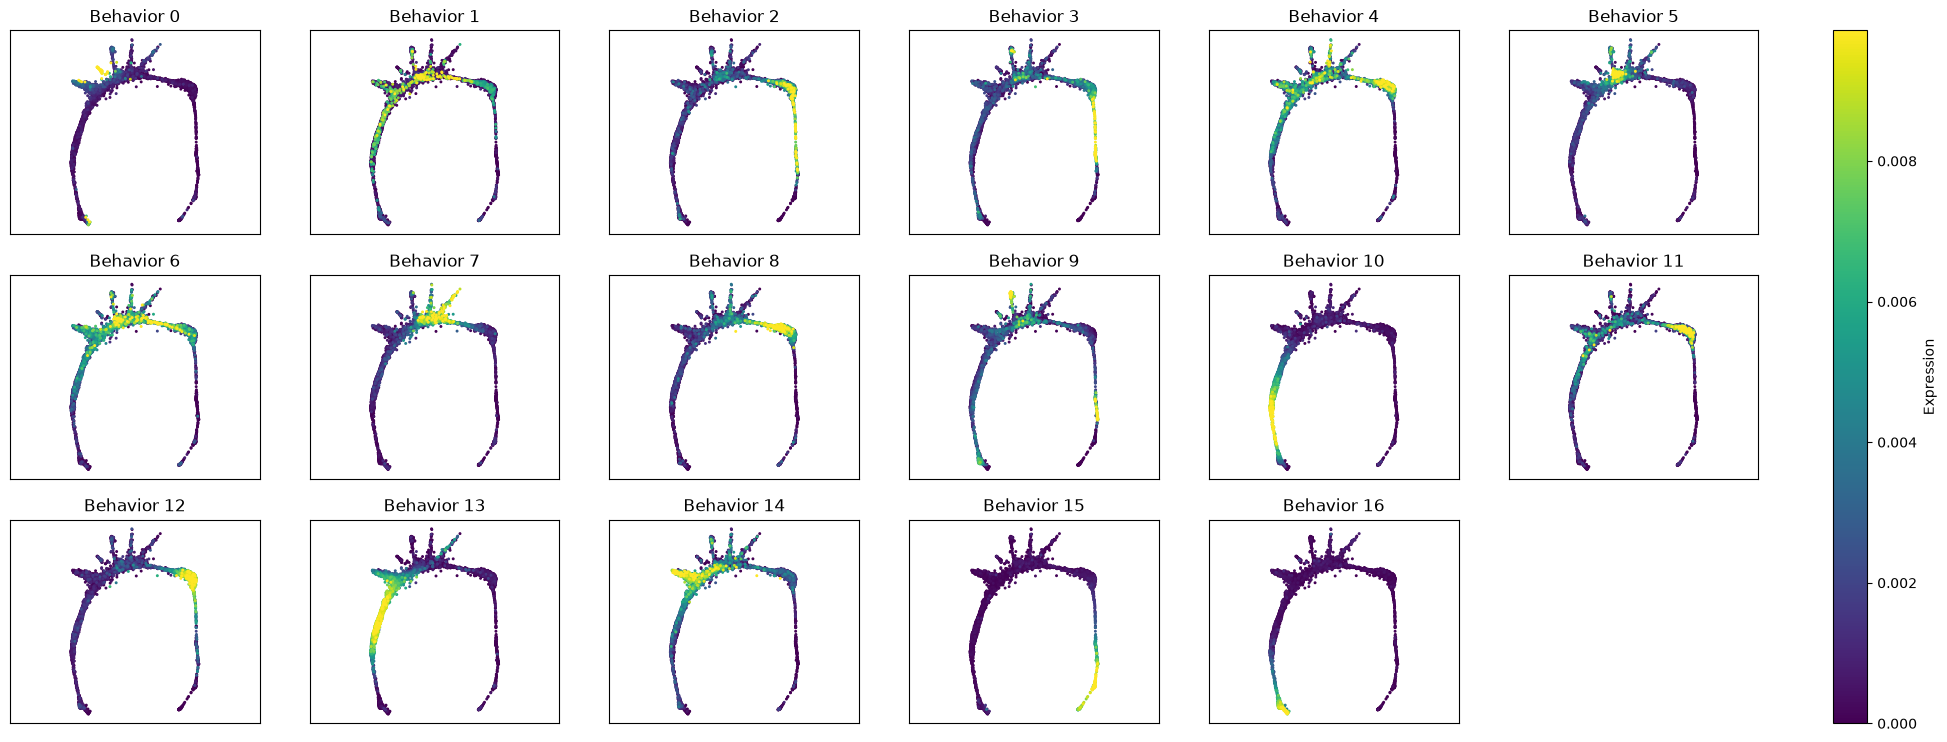

In [43]:
plotHmt = plotMultipleTusiBehaviors(behaviorExpr = Hmt.T, cellCoords = tusi_orig_coord, cols = 6, rows = 3, percentile = 99)

#### Save figure

In [44]:
plotHmt.savefig("example/Tusi1803/Tusi_scaled_17_behaviors.pdf", format="pdf", bbox_inches = "tight")